# Train XGBoost Model

## Motivation
**XGBoost** was chosen for this task for a few main reasons:

1. **High Performance** — It naturally captures complex, non-linear patterns by building a sequence of trees where each corrects the errors of the previous one.
2. **Imbalance Handling** — Our dataset is 80/20. XGBoost uses the `scale_pos_weight` parameter to heavily penalize missed alarms (False Negatives).
3. **Robustness** — It doesn't require feature scaling (`StandardScaler`) and automatically handles missing data.
4. **Interpretability** — Native `feature_importances_` allows us to easily find the top 20 features.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from time import time
import warnings
warnings.filterwarnings("ignore")
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score, matthews_corrcoef, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

data_path = Path("../data/merged/merged_preprocessed.csv")
df = pd.read_csv(data_path)

In [20]:
df["time"] = pd.to_datetime(df["time"], utc=True)

cat_cols = ["hour_conditions", "hour_preciptype", "day_of_week"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

target = "alarm"
NON_FEATURES = {"alarm", "time", "region_id", "region_city"}
features = [c for c in df.columns if c not in NON_FEATURES]

In [21]:
X = df.copy()
y = X.pop(target)

def evaluate_model(pipeline, X=X, y=y, n_splits: int = 5, gap: int = 24 * 7):
    fold_train_f1, fold_test_f1 = [[] for _ in range(n_splits)], [[] for _ in range(n_splits)]
    fold_auprc, fold_mcc = [[] for _ in range(n_splits)], [[] for _ in range(n_splits)]
    all_y_true, all_y_pred = [], []
    regions = sorted(X["region_id"].unique())
    t0 = time()

    for region_id in regions:
        mask_region = X["region_id"] == region_id
        unique_hours = X.loc[mask_region, "time"].sort_values().unique()
        tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)

        for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_hours)):
            train_mask = X["time"].isin(unique_hours[train_idx]) & mask_region
            test_mask  = X["time"].isin(unique_hours[test_idx])  & mask_region

            X_train, X_test = X[train_mask].drop(columns=["time", "region_id"]), X[test_mask].drop(columns=["time", "region_id"])
            y_train, y_test = y[train_mask], y[test_mask]

            if len(X_test) == 0: continue

            pipeline.fit(X_train, y_train)
            y_pred_train, y_pred_test = pipeline.predict(X_train), pipeline.predict(X_test)
            pred_test_proba = pipeline.predict_proba(X_test)[:, 1]

            y_train_cls, y_test_cls = (y_train > 0).astype(int), (y_test > 0).astype(int)

            fold_train_f1[fold].append(f1_score(y_train_cls, y_pred_train, zero_division=0))
            fold_test_f1[fold].append(f1_score(y_test_cls, y_pred_test, zero_division=0))
            fold_auprc[fold].append(average_precision_score(y_test_cls, pred_test_proba))
            fold_mcc[fold].append(matthews_corrcoef(y_test_cls, y_pred_test))

            all_y_true.extend(y_test_cls)
            all_y_pred.extend(y_pred_test)

    train_f1_m = [np.mean(s) for s in fold_train_f1 if s]
    test_f1_m  = [np.mean(s) for s in fold_test_f1  if s]
    auprc_m    = [np.mean(s) for s in fold_auprc if s]
    mcc_m      = [np.mean(s) for s in fold_mcc if s]

    print("\n-------- Overall --------")
    print(f"Train F1 : {np.mean(train_f1_m):.3f} ± {np.std(train_f1_m):.3f}")
    print(f"Test  F1 : {np.mean(test_f1_m):.3f} ± {np.std(test_f1_m):.3f}")
    print(f"AUPRC    : {np.mean(auprc_m):.3f} ± {np.std(auprc_m):.3f}")
    print(f"Completed in: {time() - t0:.2f}s")

    return {"train_f1": train_f1_m, "test_f1": test_f1_m, "auprc": auprc_m}, confusion_matrix(all_y_true, all_y_pred)

In [22]:
ratio = (df['alarm'] == 0).sum() / (df['alarm'] == 1).sum()
scale_weight = round(ratio, 2)
print(f"Використовуємо scale_pos_weight: {scale_weight}")

model = Pipeline([
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_weight,
        enable_categorical=True,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

scores, cm = evaluate_model(model)

Використовуємо scale_pos_weight: 3.48

-------- Overall --------
Train F1 : 0.914 ± 0.022
Test  F1 : 0.786 ± 0.079
AUPRC    : 0.860 ± 0.090
Completed in: 54.49s


## Confusion Matrix — Baseline XGBoost

**What the metrics mean:**

* **True Negative (TN):** Model correctly predicted no alarm — safe hour correctly identified.
* **False Positive (FP):** Model predicted alarm but there was none — unnecessary alert (costs attention).
* **False Negative (FN):** Model predicted no alarm but an alarm occurred — missed threat (most dangerous).
* **True Positive (TP):** Model correctly predicted an alarm — correct warning issued.

XGBoost with `scale_pos_weight` should inherently shift predictions to minimize False Negatives, prioritizing Recall over Precision.

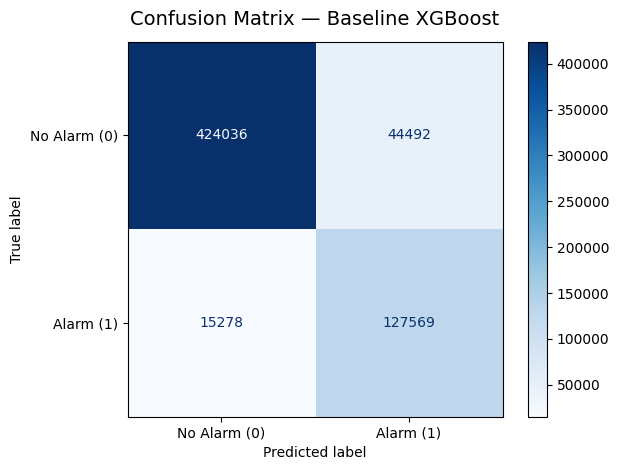

In [23]:
disp = ConfusionMatrixDisplay(cm, display_labels=["No Alarm (0)", "Alarm (1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Baseline XGBoost", fontsize=14, pad=12)
plt.grid(False)
plt.tight_layout()
plt.show()

# Hyperparameter Tuning — GridSearchCV

## Scoring metrics chosen

* **`f1`**: Balances Precision and Recall for our imbalanced 20/80 split.
* **`average_precision`**: Best for imbalanced binary classification. Summarizes Precision-Recall trade-off without being skewed by the large TN count.

## Parameters searched

* `n_estimators` (100, 300): Number of boosting rounds.
* `max_depth` (4, 6, 8): Maximum depth. Keeps individual learners relatively weak to prevent overfitting.
* `learning_rate` (0.05, 0.1): Step size shrinkage.
* `subsample` (0.8): Uses 80% of rows per tree, introducing randomness.

In [24]:
tscv_gs = TimeSeriesSplit(n_splits=3, gap=24 * 7)

param_grid = {
    "classifier__n_estimators":  [100, 300],
    "classifier__max_depth":     [4, 6, 8],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__subsample":     [0.8],
    "classifier__scale_pos_weight": [scale_weight],
}

X_gs = X.drop(columns=["time", "region_id"])

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring={"f1": "f1", "average_precision": "average_precision"},
    refit="f1",
    cv=tscv_gs,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
)

t0 = time()
grid_search.fit(X_gs, y)
print(f"\nGridSearchCV completed in: {time() - t0:.2f}s")

print("Best parameters:")
for param, val in grid_search.best_params_.items():
    print(f"  {param}: {val}")

print(f"\nBest CV F1       : {grid_search.best_score_:.4f}")
print(f"Best CV AUPRC    : {grid_search.cv_results_['mean_test_average_precision'][grid_search.best_index_]:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

GridSearchCV completed in: 510.61s
Best parameters:
  classifier__learning_rate: 0.05
  classifier__max_depth: 8
  classifier__n_estimators: 300
  classifier__scale_pos_weight: 3.48
  classifier__subsample: 0.8

Best CV F1       : 0.7851
Best CV AUPRC    : 0.8698


In [25]:
cv_results = pd.DataFrame(grid_search.cv_results_)

top5 = (
    cv_results
    .sort_values("mean_test_f1", ascending=False)
    .head(5)
    [[
        "param_classifier__n_estimators",
        "param_classifier__max_depth",
        "param_classifier__learning_rate",
        "mean_test_f1",
        "mean_test_average_precision",
    ]]
    .rename(columns=lambda c: c.replace("param_classifier__", "").replace("mean_test_", ""))
    .reset_index(drop=True)
)

top5

,n_estimators,max_depth,learning_rate,f1,average_precision
0,300,8,0.05,0.785086,0.869776
1,100,8,0.10,0.783180,0.867252
2,300,6,0.10,0.783074,0.867443
3,300,8,0.10,0.782646,0.867211
4,300,6,0.05,0.782059,0.866053


In [26]:
tuned_xgb_model = grid_search.best_estimator_

scores_tuned, cm_tuned = evaluate_model(tuned_xgb_model)


-------- Overall --------
Train F1 : 0.998 ± 0.003
Test  F1 : 0.788 ± 0.076
AUPRC    : 0.860 ± 0.095
Completed in: 226.89s


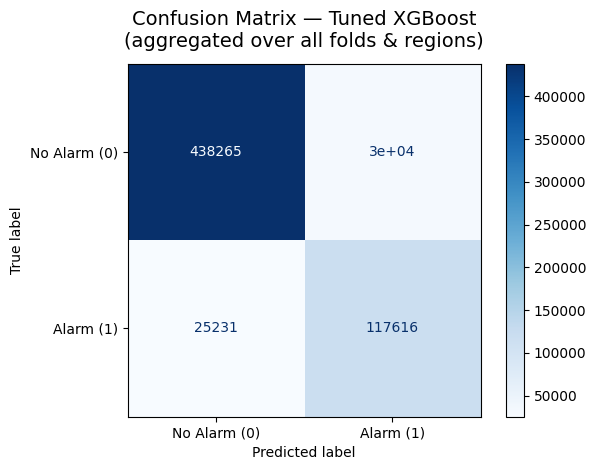

In [27]:
disp_tuned = ConfusionMatrixDisplay(
    cm_tuned,
    display_labels=["No Alarm (0)", "Alarm (1)"]
)
disp_tuned.plot(cmap="Blues")
plt.title(
    "Confusion Matrix — Tuned XGBoost\n(aggregated over all folds & regions)",
    fontsize=14, pad=12
)
plt.grid(False)
plt.tight_layout()
plt.show()

In [28]:
model_path = Path("1__xgboost__v1.pkl")

with open(model_path, "wb") as f:
    pickle.dump(tuned_xgb_model, f)

print(f"Model saved → {model_path.resolve()}")

Model saved → C:\Users\dimas\Desktop\2026_kma_ds\DS_lab\machine learning\1__xgboost__v1.pkl


# Top 20 features and weights

XGBoost provides **feature importance** based on "gain" (the average improvement in accuracy brought by a feature to the branches it is on). This tells us which features contribute the most to the model's predictive power.

In [31]:
feature_names = X.drop(columns=["time", "region_id"]).columns.tolist()

importances = tuned_xgb_model.named_steps["classifier"].feature_importances_

feat_imp = (
    pd.DataFrame({"feature": feature_names, "weight": importances})
    .sort_values("weight", ascending=False)
    .reset_index(drop=True)
)

top20 = feat_imp.head(20)
top20

,feature,weight
0,messages_count,0.215832
1,alarm_status_1h_ago,0.151184
2,nlp_повітряна_тривога,0.048539
3,msg_count_last_3h,0.039704
4,hops_to_nearest_alarm,0.039180
5,alarms_count_1h_ago,0.020551
6,nlp_дніпропетровська,0.018983
7,nlp_повітряна,0.017614
8,alarms_count_2h_ago,0.012686
9,nlp_відбій_тривоги,0.012032


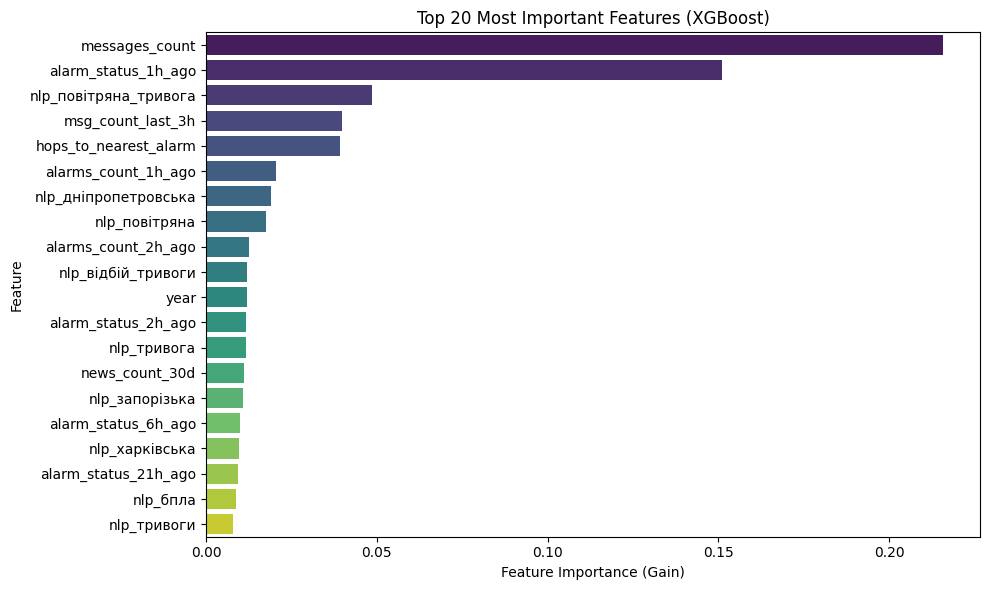

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top20,
    x="weight",
    y="feature",
    palette="viridis"
)

plt.title("Top 20 Most Important Features (XGBoost)")
plt.xlabel("Feature Importance (Gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()